# Diabetes Clinical Dataset: Exploratory Overview

An exploratory analysis of the 100,000-record diabetes clinical dataset sourced from Kaggle (Priyam Choksi). Each record is an independent anonymized patient encounter aggregated from U.S. electronic health systems across 53 states and territories.

This notebook walks through the population profile, key variable definitions, clinical feature distributions, and risk group breakdowns that motivated the modelling choices in the pipeline. Model results are covered separately in `model_results.ipynb`.

### Imports

In [51]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

COLORS = ["#4C72B0", "#DD8452"]  # blue = no diabetes, orange = diabetes

IMAGES_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "images")
os.makedirs(IMAGES_DIR, exist_ok=True)
print("Images will be saved to:", IMAGES_DIR)

raw = pd.read_csv("../../data/raw_data/diabetes_dataset.csv")

Images will be saved to: /Users/swornimbasnet/Desktop/sjsu/sp2026/cs131/Team10-ComprehensiveDiabetesClinicalDataset-health/diabetes_pipeline/visualization/images


## 1. Dataset Summary

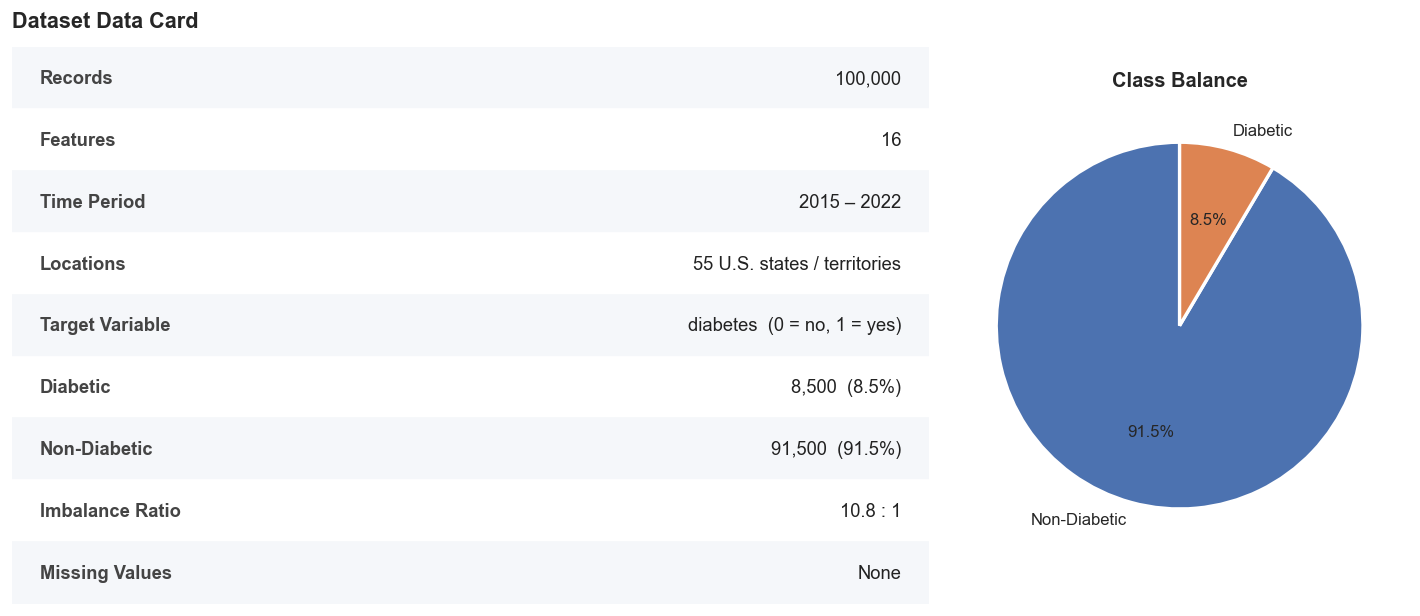

In [52]:
diabetic_count     = int(raw["diabetes"].sum())
non_diabetic_count = len(raw) - diabetic_count
year_min, year_max = int(raw["year"].min()), int(raw["year"].max())
n_locations        = raw["location"].nunique()

rows = [
    ("Records",          f"{len(raw):,}"),
    ("Features",         str(raw.shape[1])),
    ("Time Period",      f"{year_min} – {year_max}"),
    ("Locations",        f"{n_locations} U.S. states / territories"),
    ("Target Variable",  "diabetes  (0 = no, 1 = yes)"),
    ("Diabetic",         f"{diabetic_count:,}  ({diabetic_count/len(raw)*100:.1f}%)"),
    ("Non-Diabetic",     f"{non_diabetic_count:,}  ({non_diabetic_count/len(raw)*100:.1f}%)"),
    ("Imbalance Ratio",  f"{non_diabetic_count/diabetic_count:.1f} : 1"),
    ("Missing Values",   "None"),
]

fig, (ax_card, ax_pie) = plt.subplots(1, 2, figsize=(12, len(rows) * 0.5 + 0.8),
                                       gridspec_kw={"width_ratios": [2, 1]})

# Data card table
ax_card.axis("off")
for i, (label, value) in enumerate(rows):
    bg = "#f5f7fa" if i % 2 == 0 else "white"
    ax_card.add_patch(plt.Rectangle((0, i), 1, 1, transform=ax_card.transData,
                                     color=bg, zorder=0))
    ax_card.text(0.03, i + 0.5, label, va="center", ha="left",
                 fontsize=11, fontweight="bold", color="#444")
    ax_card.text(0.97, i + 0.5, value, va="center", ha="right",
                 fontsize=11, color="#222")
ax_card.set_xlim(0, 1)
ax_card.set_ylim(0, len(rows))
ax_card.invert_yaxis()
ax_card.set_title("Dataset Data Card", fontsize=13, fontweight="bold", pad=12, loc="left")

# Pie chart
ax_pie.pie(
    [non_diabetic_count, diabetic_count],
    labels=["Non-Diabetic", "Diabetic"],
    autopct="%1.1f%%",
    colors=COLORS,
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10)
)
ax_pie.set_title("Class Balance", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "data_card.png"), bbox_inches="tight")
plt.show()

### Time Period

Records span **2015 to 2022**. Distribution across years is uneven — heavily concentrated around 2019 — making this dataset unsuitable for longitudinal trend analysis. It is best treated as a cross-sectional population snapshot.

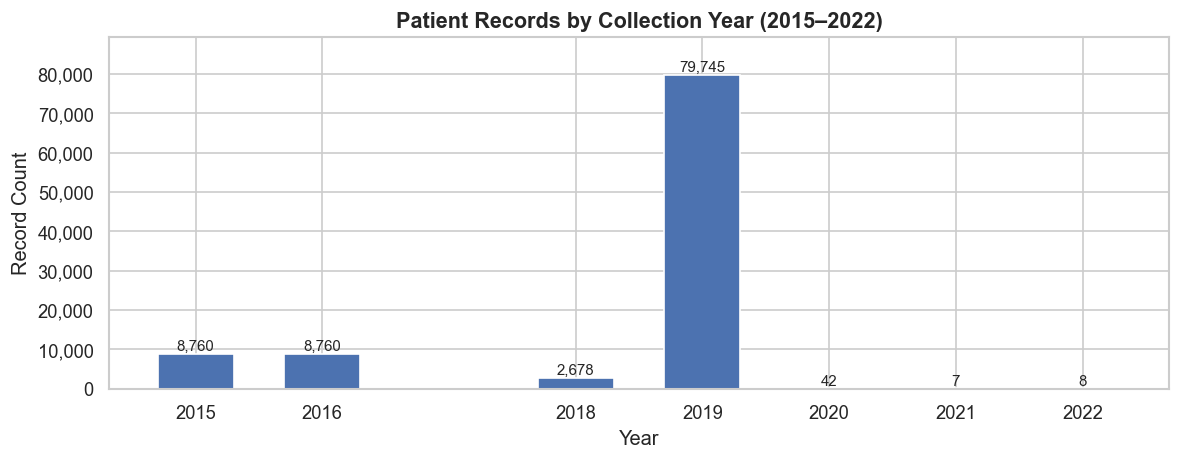

2015     8760
2016     8760
2018     2678
2019    79745
2020       42
2021        7
2022        8


In [53]:
year_counts = raw["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(year_counts.index, year_counts.values, color="#4C72B0", edgecolor="white", width=0.6)
for bar, n in zip(bars, year_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f"{n:,}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Patient Records by Collection Year (2015–2022)", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Record Count")
ax.set_xticks(year_counts.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, year_counts.max() * 1.12)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "records_by_year.png"), bbox_inches="tight")
plt.show()

print(year_counts.to_string(header=False))

No year-over-year trend analysis was performed given the uneven collection distribution.

## 2. Key Variables

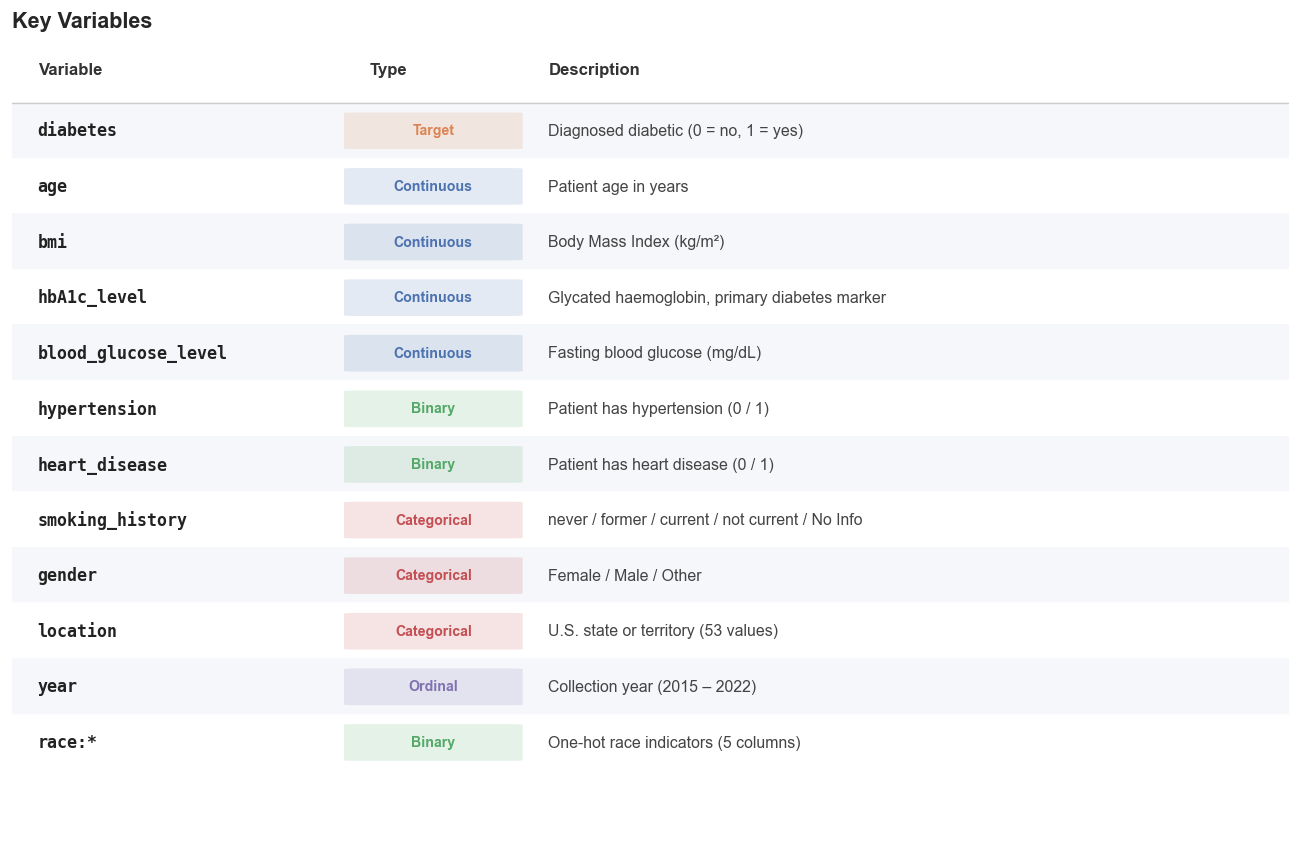

In [54]:
from matplotlib.patches import Rectangle, FancyBboxPatch

TYPE_COLORS = {
    "Target":      "#DD8452",
    "Continuous":  "#4C72B0",
    "Binary":      "#55A868",
    "Categorical": "#C44E52",
    "Ordinal":     "#8172B2",
}

variables = [
    ("diabetes",             "Target",      "Diagnosed diabetic (0 = no, 1 = yes)"),
    ("age",                  "Continuous",  "Patient age in years"),
    ("bmi",                  "Continuous",  "Body Mass Index (kg/m²)"),
    ("hbA1c_level",          "Continuous",  "Glycated haemoglobin, primary diabetes marker"),
    ("blood_glucose_level",  "Continuous",  "Fasting blood glucose (mg/dL)"),
    ("hypertension",         "Binary",      "Patient has hypertension (0 / 1)"),
    ("heart_disease",        "Binary",      "Patient has heart disease (0 / 1)"),
    ("smoking_history",      "Categorical", "never / former / current / not current / No Info"),
    ("gender",               "Categorical", "Female / Male / Other"),
    ("location",             "Categorical", "U.S. state or territory (53 values)"),
    ("year",                 "Ordinal",     "Collection year (2015 – 2022)"),
    ("race:*",               "Binary",      "One-hot race indicators (5 columns)"),
]

fig, ax = plt.subplots(figsize=(11, len(variables) * 0.52 + 1.0))
ax.axis("off")

for x, header in [(0.02, "Variable"), (0.28, "Type"), (0.42, "Description")]:
    ax.text(x, len(variables) + 0.6, header, va="center", ha="left",
            fontsize=10, fontweight="bold", color="#333")

ax.axhline(len(variables), color="#ccc", linewidth=0.8)

for i, (var, vtype, desc) in enumerate(variables):
    row = len(variables) - 1 - i
    bg = "#f5f7fa" if i % 2 == 0 else "white"
    ax.add_patch(Rectangle((0, row), 1, 1, transform=ax.transData,
                            color=bg, zorder=0))
    ax.text(0.02, row + 0.5, var, va="center", ha="left",
            fontsize=10, fontweight="bold", color="#222",
            fontfamily="monospace")
    color = TYPE_COLORS.get(vtype, "#888")
    ax.add_patch(FancyBboxPatch((0.27, row + 0.18), 0.12, 0.64,
                                 boxstyle="round,pad=0.01",
                                 linewidth=0, color=color, alpha=0.15,
                                 transform=ax.transData, zorder=1))
    ax.text(0.33, row + 0.5, vtype, va="center", ha="center",
            fontsize=8.5, color=color, fontweight="bold", zorder=2)
    ax.text(0.42, row + 0.5, desc, va="center", ha="left",
            fontsize=9.5, color="#444")

ax.set_xlim(0, 1)
ax.set_ylim(-1.2, len(variables) + 1)
ax.set_title("Key Variables", fontsize=13, fontweight="bold", pad=12, loc="left")

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "key_variables.png"), bbox_inches="tight")
plt.show()

## 3. Clinical Feature Distributions

Patient breakdown across the two primary clinical markers — HbA1c level and blood glucose — using standard diagnostic classification thresholds. These features show near-perfect class separation at their diagnostic cutoffs, which is why they dominate the Random Forest model (blood glucose: 41.8%, HbA1c: 41.6% importance).

The Logistic Regression pipeline intentionally excludes them, using only demographic and comorbidity features (age, BMI, hypertension, heart disease) to function as a pre-lab screening tool.

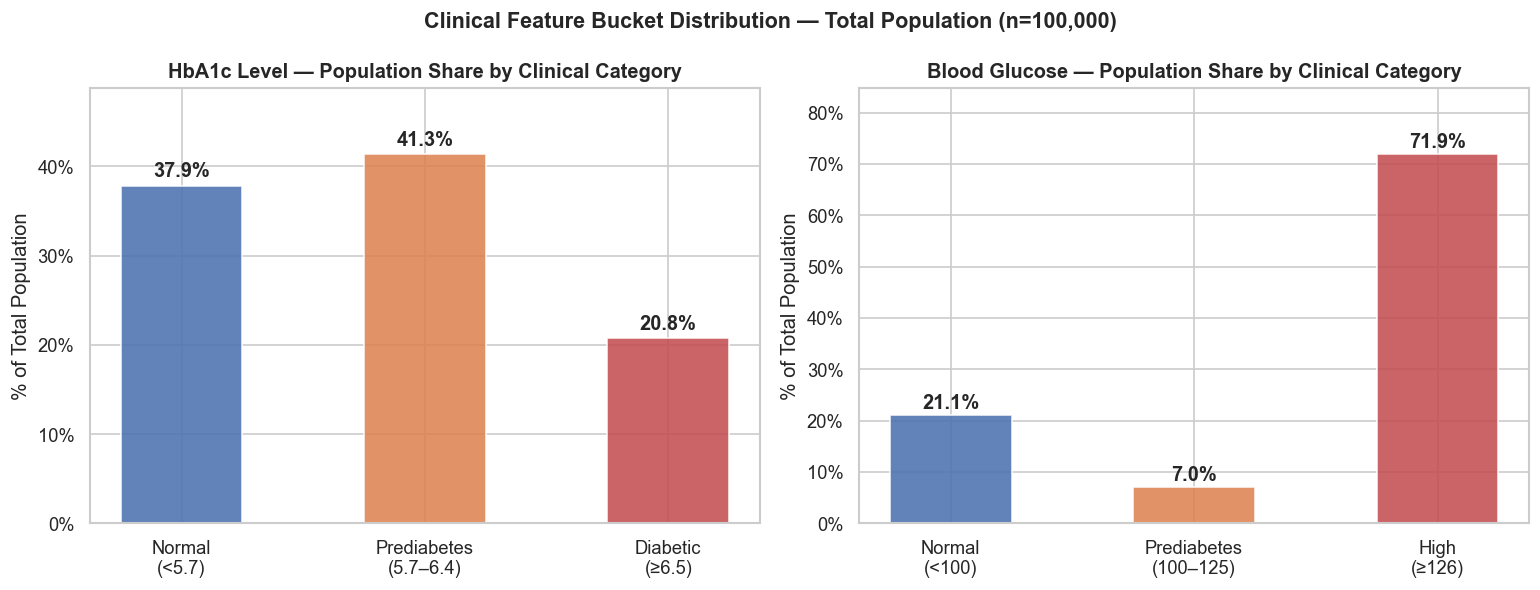

In [55]:
hba1c_bins   = [0,   5.7,  6.5,  float('inf')]
hba1c_labels = ['Normal\n(<5.7)', 'Prediabetes\n(5.7–6.4)', 'Diabetic\n(≥6.5)']

glucose_bins   = [0,   100,  126,  float('inf')]
glucose_labels = ['Normal\n(<100)', 'Prediabetes\n(100–125)', 'High\n(≥126)']

raw['hba1c_bucket']   = pd.cut(raw['hbA1c_level'],        bins=hba1c_bins,   labels=hba1c_labels,   right=False)
raw['glucose_bucket'] = pd.cut(raw['blood_glucose_level'], bins=glucose_bins, labels=glucose_labels, right=False)

hba1c_pct   = raw['hba1c_bucket'].value_counts(normalize=True).reindex(hba1c_labels) * 100
glucose_pct = raw['glucose_bucket'].value_counts(normalize=True).reindex(glucose_labels) * 100

BUCKET_COLORS = ['#4C72B0', '#DD8452', '#C44E52']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, pct, title in [
    (ax1, hba1c_pct,   'HbA1c Level — Population Share by Clinical Category'),
    (ax2, glucose_pct, 'Blood Glucose — Population Share by Clinical Category'),
]:
    bars = ax.bar(pct.index, pct.values, color=BUCKET_COLORS,
                  edgecolor='white', width=0.5, alpha=0.88)
    for bar, v in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('% of Total Population')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_ylim(0, pct.max() * 1.18)
    ax.set_axisbelow(True)

plt.suptitle('Clinical Feature Bucket Distribution — Total Population (n=100,000)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'clinical_bucket_distribution.png'), bbox_inches='tight')
plt.show()


## 4. Population Risk Analysis

Breakdown of diabetes prevalence across demographic and lifestyle dimensions — age, BMI, and comorbidity groups. These features form the basis of the Logistic Regression pre-screening model.

In [ ]:
# Build bucketed dataframe — boundaries match 06_risk_aggregation.py exactly
df = raw.copy()

df['age_bucket'] = pd.cut(df['age'],
    bins=[0, 18, 35, 55, 120],
    labels=['children', 'youth', 'adult', 'senior'],
    right=False)

df['bmi_category'] = pd.cut(df['bmi'],
    bins=[0, 18.5, 25, 30, 200],
    labels=['underweight', 'healthy', 'overweight', 'obese'],
    right=False)

print("Age bucket distribution (pipeline boundaries: <18 / 18-34 / 35-54 / ≥55):")
print(df['age_bucket'].value_counts().sort_index().to_string())
print("\nBMI category distribution:")
print(df['bmi_category'].value_counts().sort_index().to_string())

### 4.1 Diabetes Prevalence by Age Group

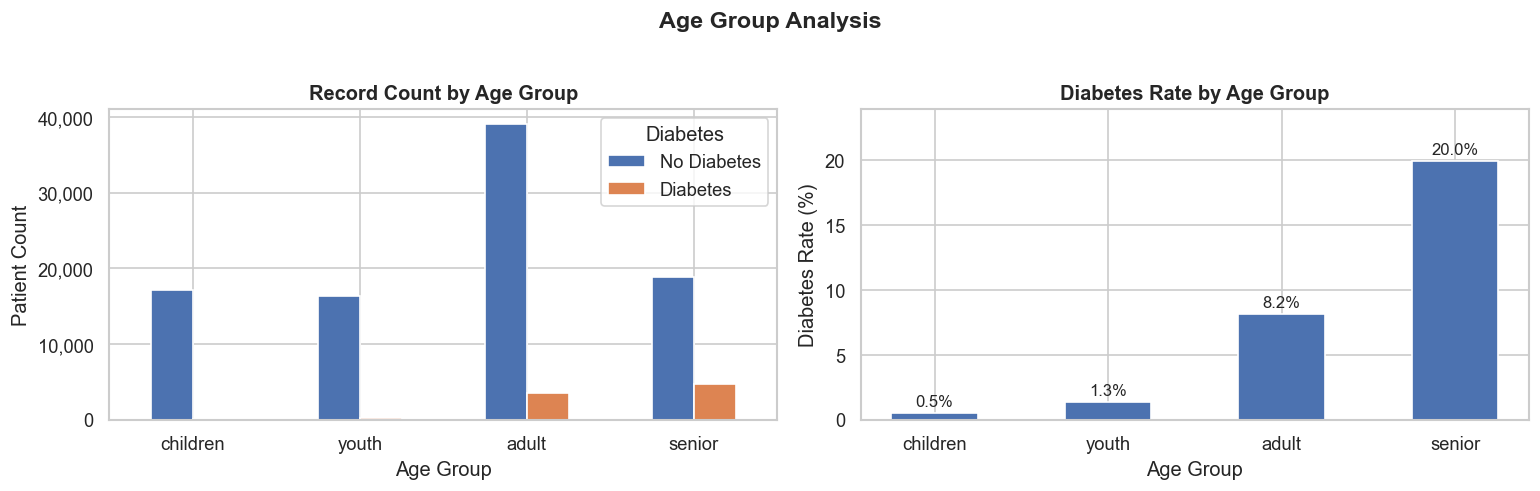

            total  diabetic       rate
age_bucket                            
children    17217        82   0.476273
youth       16513       219   1.326228
adult       42630      3477   8.156228
senior      23631      4719  19.969532


In [56]:
age_order = ["children", "youth", "adult", "senior"]

age_stats = (
    df.groupby("age_bucket")["diabetes"]
    .agg(total="count", diabetic="sum")
    .reindex(age_order)
)
age_stats["rate"] = age_stats["diabetic"] / age_stats["total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: grouped bar — counts per class
ct = df.groupby(["age_bucket", "diabetes"]).size().unstack(fill_value=0).reindex(age_order)
ct.columns = ["No Diabetes", "Diabetes"]
ct.plot(kind="bar", ax=axes[0], color=COLORS, edgecolor="white", rot=0)
axes[0].set_title("Record Count by Age Group", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Patient Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend(title="Diabetes")

# Right: diabetes rate per age group
bars = axes[1].bar(age_order, age_stats["rate"], color="#4C72B0", edgecolor="white", width=0.5)
for bar, rate in zip(bars, age_stats["rate"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{rate:.1f}%", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Diabetes Rate by Age Group", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Diabetes Rate (%)")
axes[1].set_ylim(0, age_stats["rate"].max() * 1.2)

plt.suptitle("Age Group Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "age_analysis.png"), bbox_inches="tight")
plt.show()

print(age_stats.to_string())

### 4.2 Diabetes Prevalence by BMI

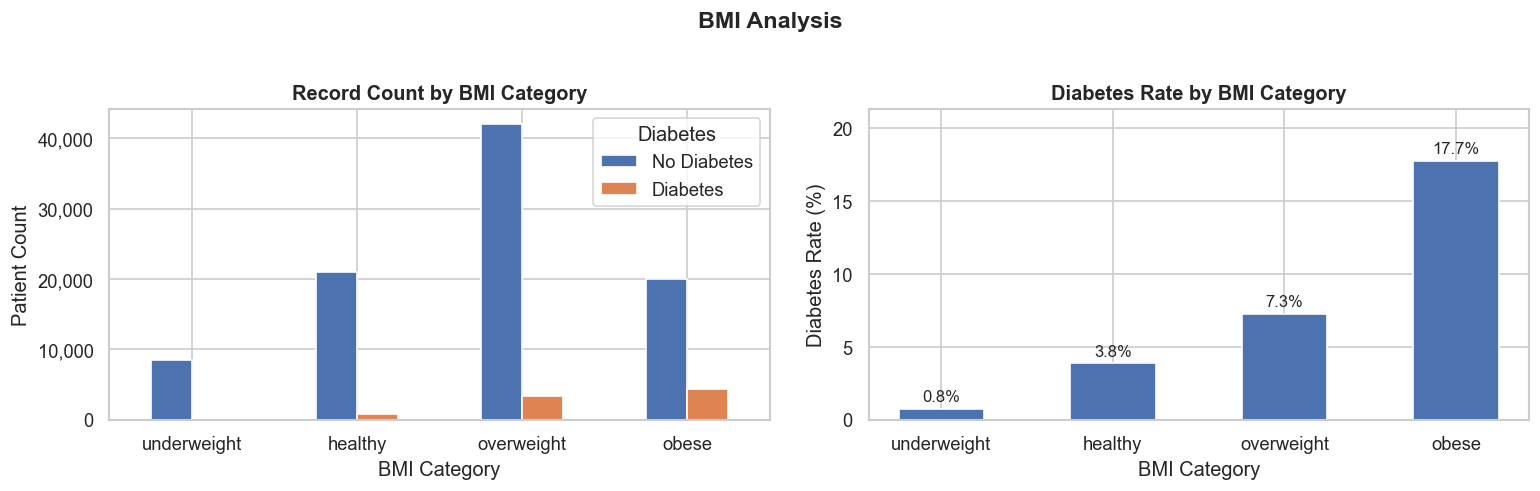

              total  diabetic       rate
bmi_category                            
underweight    8494        64   0.753473
healthy       21858       839   3.838412
overweight    45406      3295   7.256750
obese         24233      4299  17.740272


In [57]:
bmi_order = ["underweight", "healthy", "overweight", "obese"]

bmi_stats = (
    df.groupby("bmi_category")["diabetes"]
    .agg(total="count", diabetic="sum")
    .reindex(bmi_order)
)
bmi_stats["rate"] = bmi_stats["diabetic"] / bmi_stats["total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: grouped bar — counts per class
ct = df.groupby(["bmi_category", "diabetes"]).size().unstack(fill_value=0).reindex(bmi_order)
ct.columns = ["No Diabetes", "Diabetes"]
ct.plot(kind="bar", ax=axes[0], color=COLORS, edgecolor="white", rot=0)
axes[0].set_title("Record Count by BMI Category", fontsize=12, fontweight="bold")
axes[0].set_xlabel("BMI Category")
axes[0].set_ylabel("Patient Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend(title="Diabetes")

# Right: diabetes rate per BMI category
bars = axes[1].bar(bmi_order, bmi_stats["rate"], color="#4C72B0", edgecolor="white", width=0.5)
for bar, rate in zip(bars, bmi_stats["rate"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{rate:.1f}%", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Diabetes Rate by BMI Category", fontsize=12, fontweight="bold")
axes[1].set_xlabel("BMI Category")
axes[1].set_ylabel("Diabetes Rate (%)")
axes[1].set_ylim(0, bmi_stats["rate"].max() * 1.2)

plt.suptitle("BMI Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "bmi_analysis.png"), bbox_inches="tight")
plt.show()

print(bmi_stats.to_string())

### 4.3 Comorbidity: Hypertension & Heart Disease

Patients grouped into four tiers by presence of hypertension and heart disease. Having both conditions is associated with the highest diabetes rate — nearly 6× the baseline — reflecting shared underlying metabolic risk factors.

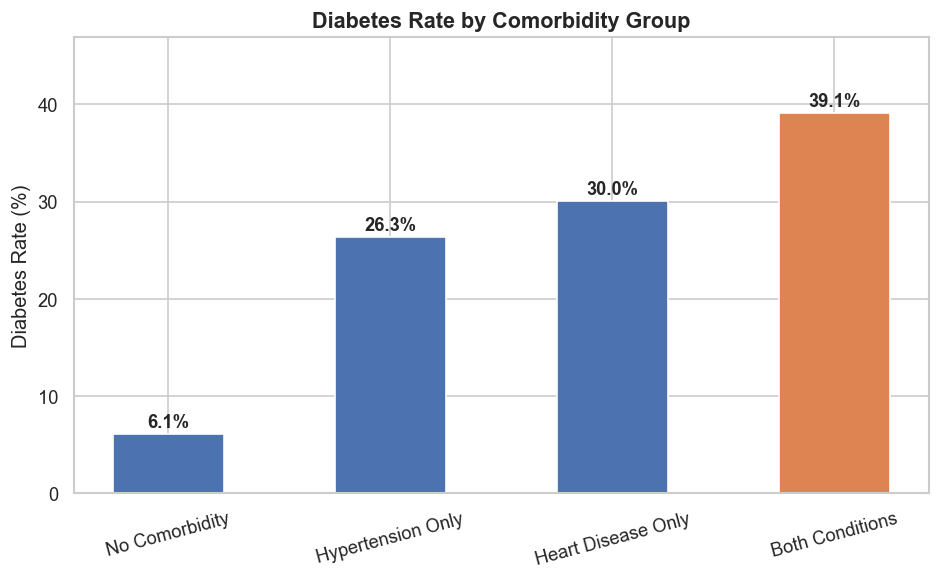

                    total  diabetic       rate
risk_group                                    
no_comorbidity      89480      5500   6.146625
hypertension_only    6569      1730  26.335820
heart_disease_only   3026       909  30.039656
both_conditions       916       358  39.082969


In [58]:
df["comorbidity"] = ((df["hypertension"] == 1) & (df["heart_disease"] == 1)).astype(int)

risk_order  = ["no_comorbidity", "hypertension_only", "heart_disease_only", "both_conditions"]
risk_labels = ["No Comorbidity", "Hypertension Only", "Heart Disease Only", "Both Conditions"]

df["risk_group"] = df.apply(lambda r:
    "both_conditions"    if r["hypertension"] == 1 and r["heart_disease"] == 1 else
    "hypertension_only"  if r["hypertension"] == 1 else
    "heart_disease_only" if r["heart_disease"] == 1 else
    "no_comorbidity", axis=1
)

risk_stats = (
    df.groupby("risk_group")["diabetes"]
    .agg(total="count", diabetic="sum")
    .reindex(risk_order)
)
risk_stats["rate"] = risk_stats["diabetic"] / risk_stats["total"] * 100

fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = ["#4C72B0", "#4C72B0", "#4C72B0", "#DD8452"]
bars = ax.bar(risk_labels, risk_stats["rate"], color=bar_colors, edgecolor="white", width=0.5)
for bar, rate in zip(bars, risk_stats["rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{rate:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Diabetes Rate by Comorbidity Group", fontsize=13, fontweight="bold")
ax.set_ylabel("Diabetes Rate (%)")
ax.set_ylim(0, risk_stats["rate"].max() * 1.2)
ax.tick_params(axis="x", rotation=15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "comorbidity_analysis.png"), bbox_inches="tight")
plt.show()

print(risk_stats[["total", "diabetic", "rate"]].to_string())


## 5. Geographic Distribution

Diabetes prevalence by U.S. state. Location is not used as a model feature — the variation across states is modest and likely reflects demographic composition rather than geography itself. Shown here for population context only.

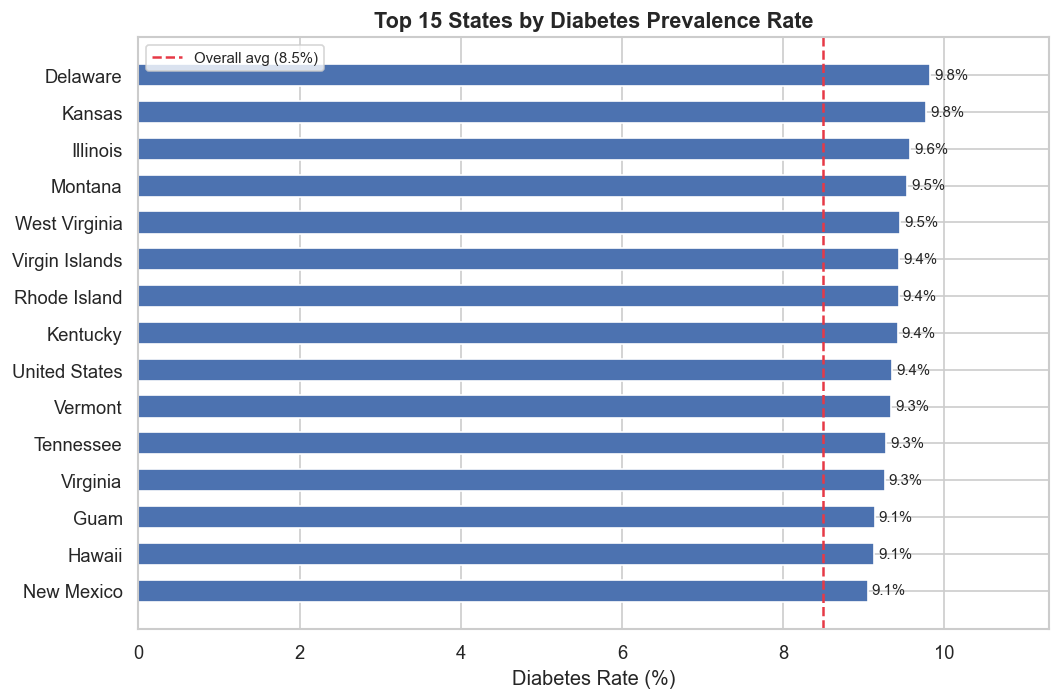

In [59]:
loc_stats = (
    raw.groupby("location")["diabetes"]
    .agg(total="count", diabetic="sum")
)
loc_stats["rate"] = loc_stats["diabetic"] / loc_stats["total"] * 100
top15 = loc_stats.sort_values("rate", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index, top15["rate"], color="#4C72B0", edgecolor="white", height=0.6)
for bar, rate in zip(bars, top15["rate"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}%", va="center", fontsize=9)
ax.axvline(raw["diabetes"].mean() * 100, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"Overall avg ({raw['diabetes'].mean()*100:.1f}%)")
ax.set_title("Top 15 States by Diabetes Prevalence Rate", fontsize=13, fontweight="bold")
ax.set_xlabel("Diabetes Rate (%)")
ax.set_xlim(0, top15["rate"].max() * 1.15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "geographic_distribution.png"), bbox_inches="tight")
plt.show()

## 6. Top 5 Highest-Risk Cohort Profiles

Cohorts ranked by diabetes prevalence rate, filtered to groups with at least 500 patients. Mirrors the logic of `scripts/rank_high_risk_profiles.py`, extended to include clinical lab value buckets alongside demographic dimensions.

In [ ]:
MIN_COHORT_SIZE = 500

# Build per-dimension cohort prevalence (mirrors rank_high_risk_profiles.py logic)
# All bucket boundaries match 06_risk_aggregation.py
raw['age_bucket'] = pd.cut(raw['age'],
    bins=[0, 18, 35, 55, 120],
    labels=['children', 'youth', 'adult', 'senior'], right=False)
raw['bmi_bucket'] = pd.cut(raw['bmi'],
    bins=[0, 18.5, 25, 30, 200],
    labels=['underweight', 'healthy', 'overweight', 'obese'], right=False)
raw['hba1c_bucket'] = pd.cut(raw['hbA1c_level'],
    bins=[0, 5.7, 6.5, float('inf')],
    labels=['Normal (<5.7)', 'Prediabetes (5.7-6.4)', 'Diabetic (>=6.5)'], right=False)
raw['glucose_bucket'] = pd.cut(raw['blood_glucose_level'],
    bins=[0, 100, 126, float('inf')],
    labels=['Normal (<100)', 'Prediabetes (100-125)', 'High (>=126)'], right=False)

LABEL_MAP = {
    'hba1c_bucket':     lambda v: f'HbA1c: {v}',
    'glucose_bucket':   lambda v: f'Blood Glucose: {v}',
    'age_bucket':       lambda v: f'Age group: {v}',
    'bmi_bucket':       lambda v: f'BMI category: {v}',
    'hypertension':     lambda v: f'Hypertension: {"Yes" if str(v)=="1" else "No"}',
    'heart_disease':    lambda v: f'Heart disease: {"Yes" if str(v)=="1" else "No"}',
    'smoking_history':  lambda v: f'Smoking status: {v}',
    'gender':           lambda v: f'Gender: {v}',
}

cohorts = []
for dim, label_fn in LABEL_MAP.items():
    for val, grp in raw.groupby(dim, observed=True):
        size = len(grp)
        if size < MIN_COHORT_SIZE:
            continue
        diabetic = grp['diabetes'].sum()
        cohorts.append({
            'label':    label_fn(val),
            'size':     size,
            'diabetic': int(diabetic),
            'rate':     diabetic / size * 100,
        })

top5 = (pd.DataFrame(cohorts)
          .sort_values(['rate', 'size'], ascending=False)
          .head(5)
          .reset_index(drop=True))
top5.index += 1

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#C44E52', '#C44E52', '#DD8452', '#DD8452', '#4C72B0']
bars = ax.barh(top5['label'][::-1], top5['rate'][::-1],
               color=bar_colors[::-1], edgecolor='white', height=0.5, alpha=0.88)

for bar, (_, row) in zip(bars, top5[::-1].iterrows()):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{row['rate']:.1f}%  (n={row['size']:,})",
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Diabetes Prevalence Rate (%)')
ax.set_title('Top 5 Highest-Risk Cohort Profiles  (min cohort size = 500)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, top5['rate'].max() * 1.35)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'top5_risk_profiles.png'), bbox_inches='tight')
plt.show()

print(top5[['label', 'size', 'diabetic', 'rate']].to_string())

## Conclusion

The dataset presents a moderately imbalanced classification problem (~8.5% diabetic) across a diverse U.S. population. Two clinical lab values — HbA1c and blood glucose — are by far the strongest individual predictors of diabetes, together accounting for over 80% of Random Forest feature importance. Demographic features (age, BMI) provide weaker but meaningful signal, particularly for pre-lab screening. Comorbidities (hypertension, heart disease) show elevated diabetes rates in population cohorts but contribute negligible discriminative power once lab values are included in the model. Geographic variation across states is present but modest, consistent with demographic composition differences rather than location-specific effects. Full model evaluation metrics and calibration results are in `model_results.ipynb`.